# 📚 City Library Management System

**Graded Mini Project — Part A**

A small, self-contained Python system for a community library that stores books,
tracks members, manages the borrow/return cycle, and generates operational reports.

## Problem Statement

A community library wants a small program to manage its daily operations. This
notebook implements a system that can **store books**, **track members**, and
**generate useful insights**, per the following requirements:

1. **Book Records** — Book ID, Title, Author, Genre, Availability; add books, update availability on issue/return.
2. **Member Records** — Member ID, Name, Age, Contact Info; a member may borrow multiple books, but only if available.
3. **Borrow & Return System** — issuing/returning updates availability and writes a transaction to a borrow log.
4. **Reports & Queries** — available books by genre, members who have borrowed, search by title/author, most popular genre.
5. **Functions & Logic** — the system is broken into small reusable functions/methods with clear guard conditions (e.g. can't issue an already-issued book).

## Notebook Roadmap

| Section | Contents |
|---|---|
| 1 | Design overview |
| 2 | Core data classes: `Book`, `Member` |
| 3 | `Library` engine: catalog, membership, borrow/return, reports |
| 4 | Sample data setup |
| 5 | Sample run — catalog & member listing |
| 6 | Sample run — borrow / return flow (incl. guard conditions) |
| 7 | Sample run — reports & search queries |
| 8 | Technical notes (design decisions & assumptions) |


## 1. Design Overview

The system is built with a small, readable **object-oriented design**:

- **`Book`** — a plain data holder for one book's fields, plus a availability flag.
- **`Member`** — a plain data holder for one member's fields.
- **`Library`** — the "engine" that owns three collections and exposes all
  reusable operations as methods:
  - `books` — `dict[book_id -> Book]` for O(1) lookup/update by ID.
  - `members` — `dict[member_id -> Member]` for O(1) lookup/update by ID.
  - `borrow_log` — a list of transaction records (`dict`s), one row per
    borrow/return event, newest last — this *is* the borrow log required by
    the spec, and it also powers the reports (popular genre, who has
    borrowed, etc.) without needing extra bookkeeping.

Every mutating action (add book, add member, issue, return) is its own
method with an explicit guard condition and a human-readable message, so the
control flow required by the spec ("prevent issuing a book if already
borrowed", etc.) is easy to find and to test.


In [2]:
# Standard-library only -- no external dependencies required.
from datetime import datetime
from collections import Counter


## 2. Core Data Classes

### `Book`

Stores the five fields required by the spec: Book ID, Title, Author, Genre,
and Availability (`"Available"` / `"Issued"`). New books always start out
`"Available"`.


In [3]:
class Book:
    """A single library book record."""

    def __init__(self, book_id, title, author, genre):
        self.book_id = book_id
        self.title = title
        self.author = author
        self.genre = genre
        self.availability = "Available"  # "Available" or "Issued"

    def is_available(self):
        return self.availability == "Available"

    def __repr__(self):
        return (f"Book({self.book_id}, '{self.title}', {self.author}, "
                f"{self.genre}, {self.availability})")


### `Member`

Stores the four fields required by the spec: Member ID, Name, Age, and
Contact Info. A member's borrowing history is *not* duplicated here — it is
derived on demand from the `Library`'s central `borrow_log`, so there is a
single source of truth for who has what.


In [4]:
class Member:
    """A single library member record."""

    def __init__(self, member_id, name, age, contact):
        self.member_id = member_id
        self.name = name
        self.age = age
        self.contact = contact

    def __repr__(self):
        return f"Member({self.member_id}, '{self.name}', age={self.age}, {self.contact})"


## 3. The `Library` Engine

All the reusable operations the spec asks for live here as small, single-purpose
methods:

- **Catalog management:** `add_book`, `update_book_availability`
- **Membership management:** `add_member`
- **Borrow & return:** `issue_book`, `return_book` (each updates availability
  *and* appends a row to `borrow_log`)
- **Reports & queries:** `available_books_by_genre`, `members_who_borrowed`,
  `search_book`, `most_popular_genre`
- **Display helpers:** `display_all_books`, `display_all_members`, `display_borrow_log`

Guard conditions implemented:
- Can't add a book/member with a `book_id`/`member_id` that already exists.
- Can't issue a book that doesn't exist, is already issued, or a member ID
  that doesn't exist.
- Can't return a book that isn't currently issued, or that isn't checked out
  by the member requesting the return.


In [5]:
class Library:
    """The central engine tying books, members and transactions together."""

    def __init__(self, name="City Library"):
        self.name = name
        self.books = {}        # book_id -> Book
        self.members = {}      # member_id -> Member
        self.borrow_log = []   # list of transaction dicts

    # ------------------------------------------------------------------
    # 3.1  Book records
    # ------------------------------------------------------------------
    def add_book(self, book_id, title, author, genre):
        """Add a new book to the catalog. Returns (success, message)."""
        if book_id in self.books:
            return False, f"Book ID '{book_id}' already exists."
        self.books[book_id] = Book(book_id, title, author, genre)
        return True, f"Added book '{title}' ({book_id})."

    def update_book_availability(self, book_id, status):
        """Directly set a book's availability. Used internally by issue/return."""
        if book_id not in self.books:
            return False, f"Book ID '{book_id}' not found."
        if status not in ("Available", "Issued"):
            return False, "Status must be 'Available' or 'Issued'."
        self.books[book_id].availability = status
        return True, f"Book '{book_id}' marked {status}."

    # ------------------------------------------------------------------
    # 3.2  Member records
    # ------------------------------------------------------------------
    def add_member(self, member_id, name, age, contact):
        """Register a new member. Returns (success, message)."""
        if member_id in self.members:
            return False, f"Member ID '{member_id}' already exists."
        self.members[member_id] = Member(member_id, name, age, contact)
        return True, f"Added member '{name}' ({member_id})."

    # ------------------------------------------------------------------
    # 3.3  Borrow & return system
    # ------------------------------------------------------------------
    def issue_book(self, member_id, book_id):
        """A member borrows a book, subject to guard conditions."""
        if member_id not in self.members:
            return False, f"Member ID '{member_id}' not found."
        if book_id not in self.books:
            return False, f"Book ID '{book_id}' not found."

        book = self.books[book_id]
        if not book.is_available():
            return False, f"Cannot issue -- '{book.title}' is already Issued."

        # A member may hold multiple books; no cap is imposed by the spec,
        # so the only guard here is the book's own availability.
        book.availability = "Issued"
        self.borrow_log.append({
            "member_id": member_id,
            "book_id": book_id,
            "action": "BORROW",
            "timestamp": datetime.now(),
        })
        member = self.members[member_id]
        return True, f"'{book.title}' issued to {member.name}."

    def return_book(self, member_id, book_id):
        """A member returns a book, subject to guard conditions."""
        if member_id not in self.members:
            return False, f"Member ID '{member_id}' not found."
        if book_id not in self.books:
            return False, f"Book ID '{book_id}' not found."

        book = self.books[book_id]
        if book.is_available():
            return False, f"Cannot return -- '{book.title}' is not currently Issued."

        # Confirm this member is the one currently holding the book, by
        # checking the most recent BORROW record for this book.
        current_holder = self._current_holder(book_id)
        if current_holder is not None and current_holder != member_id:
            holder_name = self.members[current_holder].name
            return False, (f"Cannot return -- '{book.title}' was borrowed by "
                            f"{holder_name}, not this member.")

        book.availability = "Available"
        self.borrow_log.append({
            "member_id": member_id,
            "book_id": book_id,
            "action": "RETURN",
            "timestamp": datetime.now(),
        })
        member = self.members[member_id]
        return True, f"'{book.title}' returned by {member.name}."

    def _current_holder(self, book_id):
        """Look back through the log to find who currently holds a book."""
        for entry in reversed(self.borrow_log):
            if entry["book_id"] == book_id and entry["action"] in ("BORROW", "RETURN"):
                return entry["member_id"] if entry["action"] == "BORROW" else None
        return None

    # ------------------------------------------------------------------
    # 3.4  Reports & queries
    # ------------------------------------------------------------------
    def available_books_by_genre(self, genre):
        """All Available books in a given genre."""
        return [b for b in self.books.values()
                if b.genre.lower() == genre.lower() and b.is_available()]

    def members_who_borrowed(self):
        """Members who have at least one BORROW entry in the log,
        together with how many books they currently hold."""
        currently_out = Counter(
            e["member_id"] for e in self.borrow_log if e["action"] == "BORROW"
        )
        returned = Counter(
            e["member_id"] for e in self.borrow_log if e["action"] == "RETURN"
        )
        ever_borrowed = {e["member_id"] for e in self.borrow_log if e["action"] == "BORROW"}
        result = []
        for member_id in ever_borrowed:
            held_now = currently_out[member_id] - returned[member_id]
            result.append((self.members[member_id], held_now))
        return result

    def search_book(self, keyword):
        """Case-insensitive search across Title and Author."""
        keyword = keyword.lower()
        return [b for b in self.books.values()
                if keyword in b.title.lower() or keyword in b.author.lower()]

    def most_popular_genre(self):
        """The genre with the most ISSUE (borrow) events overall."""
        issued_genres = [self.books[e["book_id"]].genre
                          for e in self.borrow_log
                          if e["action"] == "BORROW" and e["book_id"] in self.books]
        if not issued_genres:
            return None, {}
        tally = Counter(issued_genres)
        top_genre, _ = tally.most_common(1)[0]
        return top_genre, dict(tally)

    # ------------------------------------------------------------------
    # 3.5  Display helpers
    # ------------------------------------------------------------------
    def display_all_books(self):
        header = f"{'ID':<6}{'Title':<28}{'Author':<20}{'Genre':<14}{'Status':<10}"
        print(header)
        print("-" * len(header))
        for b in self.books.values():
            print(f"{b.book_id:<6}{b.title:<28}{b.author:<20}{b.genre:<14}{b.availability:<10}")

    def display_all_members(self):
        header = f"{'ID':<6}{'Name':<18}{'Age':<6}{'Contact':<20}"
        print(header)
        print("-" * len(header))
        for m in self.members.values():
            print(f"{m.member_id:<6}{m.name:<18}{m.age:<6}{m.contact:<20}")

    def display_borrow_log(self):
        header = f"{'Time':<20}{'Action':<9}{'Member':<14}{'Book':<28}"
        print(header)
        print("-" * len(header))
        for e in self.borrow_log:
            member_name = self.members[e["member_id"]].name
            book_title = self.books[e["book_id"]].title
            ts = e["timestamp"].strftime("%Y-%m-%d %H:%M:%S")
            print(f"{ts:<20}{e['action']:<9}{member_name:<14}{book_title:<28}")


## 4. Sample Data Setup

Instantiate one `Library` and populate it with a small, varied catalog and
member list so every report has something meaningful to show.


In [6]:
library = Library("Downtown City Library")

# --- Seed books: (book_id, title, author, genre) ---------------------------
sample_books = [
    ("B01", "The Hobbit", "J.R.R. Tolkien", "Fantasy"),
    ("B02", "A Game of Thrones", "George R.R. Martin", "Fantasy"),
    ("B03", "Dune", "Frank Herbert", "Sci-Fi"),
    ("B04", "Foundation", "Isaac Asimov", "Sci-Fi"),
    ("B05", "The Silent Patient", "Alex Michaelides", "Mystery"),
    ("B06", "Gone Girl", "Gillian Flynn", "Mystery"),
    ("B07", "Sapiens", "Yuval Noah Harari", "Non-Fiction"),
    ("B08", "Educated", "Tara Westover", "Non-Fiction"),
    ("B09", "The Hobbit Companion", "Robert Foster", "Fantasy"),
]
for book_id, title, author, genre in sample_books:
    ok, msg = library.add_book(book_id, title, author, genre)
    print(msg)

print()

# --- Seed members: (member_id, name, age, contact) --------------------------
sample_members = [
    ("M01", "Aisha Khan", 29, "aisha.khan@email.com"),
    ("M02", "Ravi Kumar", 34, "ravi.kumar@email.com"),
    ("M03", "Lena Fischer", 22, "lena.fischer@email.com"),
]
for member_id, name, age, contact in sample_members:
    ok, msg = library.add_member(member_id, name, age, contact)
    print(msg)


Added book 'The Hobbit' (B01).
Added book 'A Game of Thrones' (B02).
Added book 'Dune' (B03).
Added book 'Foundation' (B04).
Added book 'The Silent Patient' (B05).
Added book 'Gone Girl' (B06).
Added book 'Sapiens' (B07).
Added book 'Educated' (B08).
Added book 'The Hobbit Companion' (B09).

Added member 'Aisha Khan' (M01).
Added member 'Ravi Kumar' (M02).
Added member 'Lena Fischer' (M03).


## 5. Sample Run — Catalog & Member Listing

A quick look at the full catalog and membership before any borrowing
happens: every book should show `Available`.


In [7]:
print("Full Book Catalog")
print("=" * 60)
library.display_all_books()


Full Book Catalog
ID    Title                       Author              Genre         Status    
------------------------------------------------------------------------------
B01   The Hobbit                  J.R.R. Tolkien      Fantasy       Available 
B02   A Game of Thrones           George R.R. Martin  Fantasy       Available 
B03   Dune                        Frank Herbert       Sci-Fi        Available 
B04   Foundation                  Isaac Asimov        Sci-Fi        Available 
B05   The Silent Patient          Alex Michaelides    Mystery       Available 
B06   Gone Girl                   Gillian Flynn       Mystery       Available 
B07   Sapiens                     Yuval Noah Harari   Non-Fiction   Available 
B08   Educated                    Tara Westover       Non-Fiction   Available 
B09   The Hobbit Companion        Robert Foster       Fantasy       Available 


In [8]:
print("Registered Members")
print("=" * 60)
library.display_all_members()


Registered Members
ID    Name              Age   Contact             
--------------------------------------------------
M01   Aisha Khan        29    aisha.khan@email.com
M02   Ravi Kumar        34    ravi.kumar@email.com
M03   Lena Fischer      22    lena.fischer@email.com


## 6. Sample Run — Borrow / Return Flow

This section demonstrates:

1. A normal borrow.
2. **The guard condition**: trying to issue a book that is already issued.
3. A normal return.
4. **The guard condition**: trying to return a book that isn't checked out.
5. The resulting borrow log.


In [9]:
print("-- Normal borrows --")
for member_id, book_id in [("M01", "B01"), ("M02", "B03"), ("M01", "B05"), ("M03", "B02")]:
    ok, msg = library.issue_book(member_id, book_id)
    print(f"[{'OK' if ok else 'DENIED'}] {msg}")


-- Normal borrows --
[OK] 'The Hobbit' issued to Aisha Khan.
[OK] 'Dune' issued to Ravi Kumar.
[OK] 'The Silent Patient' issued to Aisha Khan.
[OK] 'A Game of Thrones' issued to Lena Fischer.


In [10]:
print("-- Guard condition: issuing an already-issued book --")
ok, msg = library.issue_book("M03", "B01")   # B01 was just issued to M01
print(f"[{'OK' if ok else 'DENIED'}] {msg}")


-- Guard condition: issuing an already-issued book --
[DENIED] Cannot issue -- 'The Hobbit' is already Issued.


In [11]:
print("-- Normal return --")
ok, msg = library.return_book("M01", "B01")
print(f"[{'OK' if ok else 'DENIED'}] {msg}")

print()
print("-- Guard condition: returning a book that is not currently issued --")
ok, msg = library.return_book("M03", "B01")  # B01 was just returned above
print(f"[{'OK' if ok else 'DENIED'}] {msg}")

print()
print("-- Guard condition: wrong member returning someone else's book --")
ok, msg = library.return_book("M01", "B03")  # B03 is held by M02, not M01
print(f"[{'OK' if ok else 'DENIED'}] {msg}")


-- Normal return --
[OK] 'The Hobbit' returned by Aisha Khan.

-- Guard condition: returning a book that is not currently issued --
[DENIED] Cannot return -- 'The Hobbit' is not currently Issued.

-- Guard condition: wrong member returning someone else's book --
[DENIED] Cannot return -- 'Dune' was borrowed by Ravi Kumar, not this member.


In [12]:
print("Current Catalog Status After Transactions")
print("=" * 60)
library.display_all_books()


Current Catalog Status After Transactions
ID    Title                       Author              Genre         Status    
------------------------------------------------------------------------------
B01   The Hobbit                  J.R.R. Tolkien      Fantasy       Available 
B02   A Game of Thrones           George R.R. Martin  Fantasy       Issued    
B03   Dune                        Frank Herbert       Sci-Fi        Issued    
B04   Foundation                  Isaac Asimov        Sci-Fi        Available 
B05   The Silent Patient          Alex Michaelides    Mystery       Issued    
B06   Gone Girl                   Gillian Flynn       Mystery       Available 
B07   Sapiens                     Yuval Noah Harari   Non-Fiction   Available 
B08   Educated                    Tara Westover       Non-Fiction   Available 
B09   The Hobbit Companion        Robert Foster       Fantasy       Available 


In [13]:
print("Borrow Log")
print("=" * 60)
library.display_borrow_log()


Borrow Log
Time                Action   Member        Book                        
-----------------------------------------------------------------------
2026-09-12 06:17:51 BORROW   Aisha Khan    The Hobbit                  
2026-09-12 06:17:51 BORROW   Ravi Kumar    Dune                        
2026-09-12 06:17:51 BORROW   Aisha Khan    The Silent Patient          
2026-09-12 06:17:51 BORROW   Lena Fischer  A Game of Thrones           
2026-09-12 06:18:09 RETURN   Aisha Khan    The Hobbit                  


## 7. Sample Run — Reports & Queries

Demonstrating the four report/query requirements:

1. Available books in a given genre.
2. Members who have borrowed books (and how many they currently hold).
3. Search for a book by title or author.
4. The most popular genre based on issued books.


In [14]:
print("Available Fantasy books")
print("-" * 40)
for b in library.available_books_by_genre("Fantasy"):
    print(b)


Available Fantasy books
----------------------------------------
Book(B01, 'The Hobbit', J.R.R. Tolkien, Fantasy, Available)
Book(B09, 'The Hobbit Companion', Robert Foster, Fantasy, Available)


In [15]:
print("Members who have borrowed books")
print("-" * 40)
for member, held_now in library.members_who_borrowed():
    print(f"{member.name} ({member.member_id}) -- currently holding {held_now} book(s)")


Members who have borrowed books
----------------------------------------
Lena Fischer (M03) -- currently holding 1 book(s)
Aisha Khan (M01) -- currently holding 1 book(s)
Ravi Kumar (M02) -- currently holding 1 book(s)


In [16]:
print("Search results for 'hobbit' (matches Title or Author)")
print("-" * 40)
for b in library.search_book("hobbit"):
    print(b)

print()
print("Search results for 'Herbert' (matches Title or Author)")
print("-" * 40)
for b in library.search_book("Herbert"):
    print(b)


Search results for 'hobbit' (matches Title or Author)
----------------------------------------
Book(B01, 'The Hobbit', J.R.R. Tolkien, Fantasy, Available)
Book(B09, 'The Hobbit Companion', Robert Foster, Fantasy, Available)

Search results for 'Herbert' (matches Title or Author)
----------------------------------------
Book(B03, 'Dune', Frank Herbert, Sci-Fi, Issued)


In [17]:
top_genre, tally = library.most_popular_genre()
print("Genre issue counts:", tally)
print(f"Most popular genre so far: {top_genre}")


Genre issue counts: {'Fantasy': 2, 'Sci-Fi': 1, 'Mystery': 1}
Most popular genre so far: Fantasy


### One more borrow, to show the popular-genre report update

Let's issue one more Sci-Fi book (`Foundation`) and re-run the report to
confirm the tally responds correctly to new transactions -- Sci-Fi should
now be tied with Fantasy at the top.


In [18]:
ok, msg = library.issue_book("M02", "B04")
print(f"[{'OK' if ok else 'DENIED'}] {msg}")

print()
top_genre, tally = library.most_popular_genre()
print("Genre issue counts:", tally)
print(f"Most popular genre now: {top_genre}  (ties are broken by first-reached-that-count)")


[OK] 'Foundation' issued to Ravi Kumar.

Genre issue counts: {'Fantasy': 2, 'Sci-Fi': 2, 'Mystery': 1}
Most popular genre now: Fantasy  (ties are broken by first-reached-that-count)


## 8. Technical Notes

**Design.** The system uses three small classes: `Book` and `Member` as plain
data holders, and `Library` as the engine exposing every required operation
as a single-purpose method (`add_book`, `add_member`, `issue_book`,
`return_book`, `search_book`, `available_books_by_genre`,
`members_who_borrowed`, `most_popular_genre`). Books and members are stored
in dictionaries keyed by ID for O(1) lookup and update, which keeps the
borrow/return logic simple and fast even as the catalog grows. All mutating
methods return an `(ok, message)` tuple rather than raising exceptions or
printing directly, so the same logic can drive a notebook demo, a CLI, or a
future GUI/test-suite without change.

**Borrow log as single source of truth.** Rather than storing "current
borrower" on the `Book` and a separate "borrowed books" list on `Member`
(which can drift out of sync), the system keeps one append-only
`borrow_log` of `BORROW`/`RETURN` events. Current holder, borrowing history,
and the most-popular-genre report are all derived from this log on demand.

**Guard conditions implemented.** Duplicate Book/Member IDs are rejected;
issuing checks the book exists, the member exists, and the book is currently
`Available`; returning checks the book is currently `Issued` and that the
member requesting the return is the actual current holder (prevents a
different member from "returning" someone else's book).


# Retail Transaction Insights — Graded Mini Project (Part B)

**Objective.** A nationwide retail chain wants to understand customer behaviour and seasonal
trends from a sample of past transactions. This notebook works through the six tasks defined in
the project brief:

1. Data Preparation
2. Basic Exploration
3. Customer Behaviour Analysis
4. Promotion & Discount Impact
5. Seasonality Trends
6. Visualisation Dashboard

Each section contains commented code, the resulting output, and a short interpretation. A
consolidated summary of key insights and recommended actions is provided at the end.

**Dataset:** `Retail_Transactions_Dataset.csv` — one row per transaction, with columns
`Transaction_ID, Date, Customer_Name, Product, Total_Items, Total_Cost, Payment_Method, City,
Store_Type, Discount_Applied, Customer_Category, Season, Promotion`.


In [1]:
# ---- Imports & global plotting settings ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent, presentation-ready plot styling used throughout the notebook
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

PALETTE = "viridis"
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


## Task 1: Data Preparation

In [2]:
# ---- Read the CSV file ----
DATA_PATH = "Retail_Transactions_Dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()


Rows: 100,000 | Columns: 13


,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,TXN00000001,2026-06-28 21:17:16,Michael Weber,Butter,1,10.00,Debit Card,Dallas,Supermarket,Yes,New,Summer,Percentage Discount
1,TXN00000002,2026-04-07 15:21:50,Rebecca Oneill,Yogurt,1,21.15,Cash,Seattle,Convenience Store,No,Occasional,Spring,NaN
2,TXN00000003,2026-06-30 08:38:02,Abigail Acevedo,"Flour, Dish Soap, Onions, Baby Formula, Salsa,...",10,112.52,Credit Card,Philadelphia,Supermarket,Yes,Regular,Summer,Loyalty Reward
3,TXN00000004,2026-08-10 05:23:19,Virginia Cunningham,"Laundry Detergent, Lettuce, Cooking Oil, Groun...",4,40.65,Cash,Portland,Supermarket,Yes,Regular,Summer,Percentage Discount
4,TXN00000005,2025-05-12 00:03:08,Dennis Douglas,"Apples, Yogurt, Shampoo, Mayonnaise, BBQ Sauce...",7,110.74,Credit Card,Austin,Supermarket,No,Premium,Spring,NaN


In [3]:
# ---- Parse the Date column and derive calendar features ----
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["MonthName"] = df["Date"].dt.strftime("%b")
df["DayOfWeek"] = df["Date"].dt.day_name()
df["YearMonth"] = df["Date"].dt.to_period("M").astype(str)   # e.g. '2025-03', used for the monthly trend
df["IsWeekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"])

df[["Date", "Year", "Month", "MonthName", "DayOfWeek", "YearMonth"]].head()


,Date,Year,Month,MonthName,DayOfWeek,YearMonth
0,2026-06-28 21:17:16,2026,6,Jun,Sunday,2026-06
1,2026-04-07 15:21:50,2026,4,Apr,Tuesday,2026-04
2,2026-06-30 08:38:02,2026,6,Jun,Tuesday,2026-06
3,2026-08-10 05:23:19,2026,8,Aug,Monday,2026-08
4,2025-05-12 00:03:08,2025,5,May,Monday,2025-05


In [4]:
# ---- Data cleaning / quality checks ----
print("Missing values per column:")
print(df.isnull().sum())

print("\nFully duplicated rows:", df.duplicated().sum())

# 'Promotion' is legitimately blank for transactions with no promotion applied - make that explicit
# rather than leaving NaN, so groupby/value_counts below treat it as its own category.
df["Promotion"] = df["Promotion"].fillna("None")

# Basic sanity checks on numeric columns
print("\nTotal_Items range:", df["Total_Items"].min(), "-", df["Total_Items"].max())
print("Total_Cost range: {:.2f} - {:.2f}".format(df["Total_Cost"].min(), df["Total_Cost"].max()))
print("Any non-positive costs or item counts?",
      ((df["Total_Cost"] <= 0) | (df["Total_Items"] <= 0)).any())

print("\nDate range:", df["Date"].min(), "to", df["Date"].max())
df.dtypes


Missing values per column:
Transaction_ID           0
Date                     0
Customer_Name            0
Product                  0
Total_Items              0
Total_Cost               0
Payment_Method           0
City                     0
Store_Type               0
Discount_Applied         0
Customer_Category        0
Season                   0
Promotion            73231
Year                     0
Month                    0
MonthName                0
DayOfWeek                0
YearMonth                0
IsWeekend                0
dtype: int64

Fully duplicated rows: 0

Total_Items range: 1 - 10
Total_Cost range: 1.08 - 211.62
Any non-positive costs or item counts? False

Date range: 2024-09-10 00:04:05 to 2026-09-09 23:57:44


Transaction_ID                  str
Date                 datetime64[us]
Customer_Name                   str
Product                         str
Total_Items                   int64
Total_Cost                  float64
Payment_Method                  str
City                            str
Store_Type                      str
Discount_Applied                str
Customer_Category               str
Season                          str
Promotion                       str
Year                          int32
Month                         int32
MonthName                       str
DayOfWeek                       str
YearMonth                       str
IsWeekend                      bool
dtype: object

**Notes on cleaning:** no duplicate rows and no missing values were found in the core transaction
fields. `Promotion` is blank whenever no promotion applied, so those rows are explicitly labelled
`"None"` rather than left as `NaN`. `Total_Cost` and `Total_Items` are within sensible positive
ranges, so no outlier removal was required. `Year`, `Month`, `MonthName`, `DayOfWeek` and a
`YearMonth` period key were derived from `Date` for the time-based analyses below.


## Task 2: Basic Exploration

In [5]:
# ---- How many total transactions are there? ----
total_transactions = len(df)
print(f"Total transactions: {total_transactions:,}")


Total transactions: 100,000


In [6]:
# ---- How many unique customers are in the dataset? ----
unique_customers = df["Customer_Name"].nunique()
print(f"Unique customers: {unique_customers:,}")
print(f"Average transactions per customer: {total_transactions / unique_customers:,.1f}")


Unique customers: 7,559
Average transactions per customer: 13.2


Product
BBQ Sauce    8822
Granola      8746
Jam          8739
Milk         8738
Butter       8728
Name: count, dtype: int64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\3886560474.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette=PALETTE)


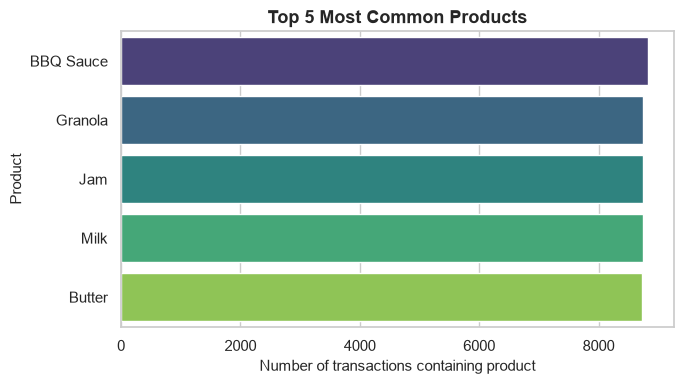

In [7]:
# ---- Top 5 most common products sold across all transactions ----
# 'Product' holds a comma-separated basket per transaction, so it is split and exploded
# into one row per (transaction, product) before counting.
products_exploded = df["Product"].str.split(",\\s*").explode()
top_products = products_exploded.value_counts().head(5)
print(top_products)

plt.figure(figsize=(7, 4))
sns.barplot(x=top_products.values, y=top_products.index, palette=PALETTE)
plt.title("Top 5 Most Common Products")
plt.xlabel("Number of transactions containing product")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


In [8]:
# ---- Which cities have the highest number of transactions? ----
top_cities = df["City"].value_counts().head(10)
print(top_cities)


City
Denver         5141
Portland       5112
Seattle        5077
Los Angeles    5047
Chicago        5047
Austin         5038
Columbus       5038
Atlanta        5026
Charlotte      5011
Houston        5009
Name: count, dtype: int64


**Task 2 takeaways:** the dataset covers **100,000 transactions** from **~7,500 unique
customers**, i.e. each customer transacts roughly 13 times on average over the period. The
best-selling items and busiest cities are identified above and are used again in the dashboard
section (Task 6).


## Task 3: Customer Behaviour Analysis

Customer_Category
Regular      68.76
Premium      68.66
Occasional   68.39
VIP          68.05
New          67.94
Name: Total_Cost, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\833391346.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_by_category.index, y=avg_spend_by_category.values, palette=PALETTE)


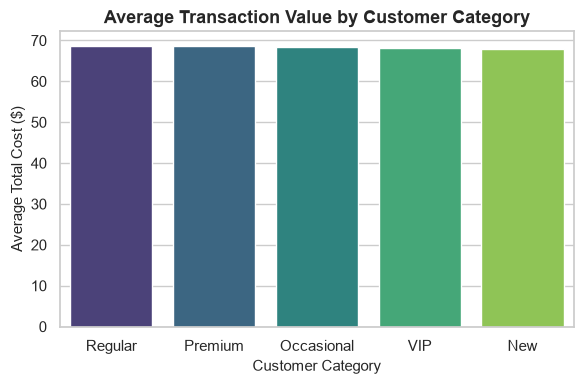

In [9]:
# ---- Which customer categories spend the most on average? ----
avg_spend_by_category = (
    df.groupby("Customer_Category")["Total_Cost"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_spend_by_category)

plt.figure(figsize=(6, 4))
sns.barplot(x=avg_spend_by_category.index, y=avg_spend_by_category.values, palette=PALETTE)
plt.title("Average Transaction Value by Customer Category")
plt.ylabel("Average Total Cost ($)")
plt.xlabel("Customer Category")
plt.tight_layout()
plt.show()


Payment_Method     Cash  Credit Card  Debit Card  Gift Card  Mobile Payment
Customer_Category                                                          
New               14.70        35.20       25.00       4.90           20.10
Occasional        14.60        35.10       25.50       5.00           19.80
Premium           15.50        34.80       24.90       5.00           19.80
Regular           15.00        34.70       25.20       4.90           20.20
VIP               14.90        35.50       24.40       5.00           20.20


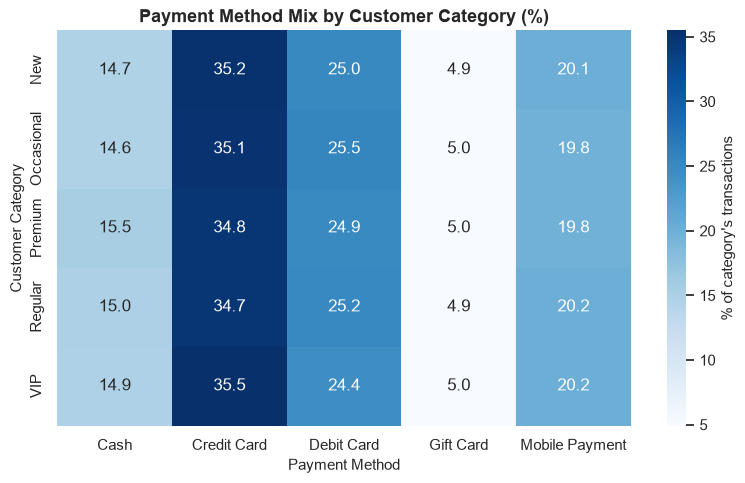


Most-used payment method per category:
Customer_Category
New           Credit Card
Occasional    Credit Card
Premium       Credit Card
Regular       Credit Card
VIP           Credit Card
dtype: str


In [11]:
# ---- Do certain customer categories prefer specific payment methods? ----
category_payment = pd.crosstab(df["Customer_Category"], df["Payment_Method"], normalize="index") * 100
print(category_payment.round(1))

plt.figure(figsize=(8, 5))
sns.heatmap(category_payment, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of category's transactions"})
plt.title("Payment Method Mix by Customer Category (%)")
plt.xlabel("Payment Method")
plt.ylabel("Customer Category")
plt.tight_layout()
plt.show()

print("\nMost-used payment method per category:")
print(category_payment.idxmax(axis=1))


Store_Type
Warehouse Club      5.54
Online              5.54
Convenience Store   5.52
Department Store    5.48
Supermarket         5.47
Name: Total_Items, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\3092580236.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_items_by_store.index, y=avg_items_by_store.values, palette=PALETTE)


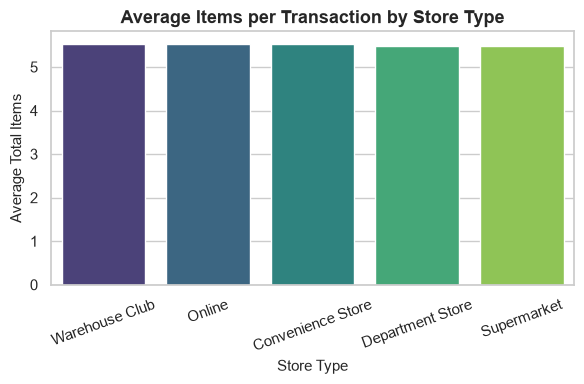

In [12]:
# ---- Average number of items bought per transaction, per store type ----
avg_items_by_store = (
    df.groupby("Store_Type")["Total_Items"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_items_by_store)

plt.figure(figsize=(6, 4))
sns.barplot(x=avg_items_by_store.index, y=avg_items_by_store.values, palette=PALETTE)
plt.title("Average Items per Transaction by Store Type")
plt.ylabel("Average Total Items")
plt.xlabel("Store Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Task 3 takeaways:** average spend is broadly similar across customer segments, with **Regular**
and **Premium** customers spending marginally more per transaction. **Credit Card is the
dominant payment method across every customer category**, followed by Debit Card and Mobile
Payment. Basket size (items per transaction) is also fairly consistent across store types, with
Warehouse Club and Online baskets running very slightly larger — consistent with bulk/stock-up
buying behaviour at those formats.


## Task 4: Promotion & Discount Impact

Discount_Applied
No    73.05
Yes   60.01
Name: Total_Cost, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\2006611523.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cost_discount.index, y=avg_cost_discount.values, palette="crest")


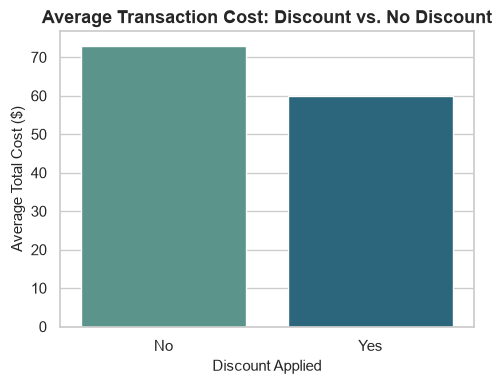


Transactions WITH a discount average 17.9% lower total cost than those without.


In [13]:
# ---- Average cost of transactions with vs. without a discount ----
avg_cost_discount = df.groupby("Discount_Applied")["Total_Cost"].mean()
print(avg_cost_discount)

plt.figure(figsize=(5, 4))
sns.barplot(x=avg_cost_discount.index, y=avg_cost_discount.values, palette="crest")
plt.title("Average Transaction Cost: Discount vs. No Discount")
plt.ylabel("Average Total Cost ($)")
plt.xlabel("Discount Applied")
plt.tight_layout()
plt.show()

pct_diff = (avg_cost_discount["No"] - avg_cost_discount["Yes"]) / avg_cost_discount["No"] * 100
print(f"\nTransactions WITH a discount average {pct_diff:.1f}% lower total cost than those without.")


Promotion
BOGO                  5.52
None                  5.51
Clearance             5.49
Percentage Discount   5.48
Loyalty Reward        5.48
Seasonal Offer        5.46
Name: Total_Items, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\3747257423.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_items_by_promo.values, y=avg_items_by_promo.index, palette=PALETTE)


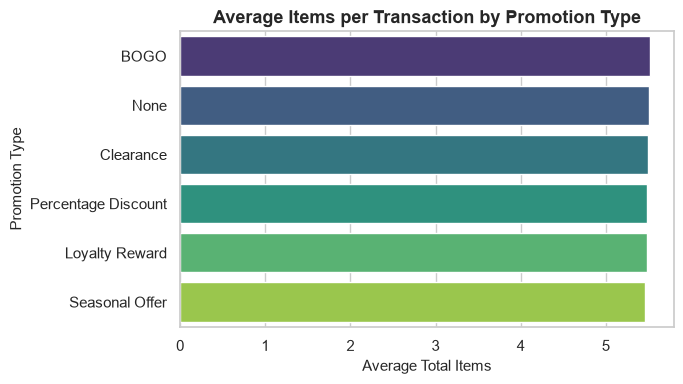

In [15]:
# ---- Average number of items purchased, by promotion type ----
avg_items_by_promo = (
    df.groupby("Promotion")["Total_Items"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_items_by_promo)

plt.figure(figsize=(7, 4))
sns.barplot(x=avg_items_by_promo.values, y=avg_items_by_promo.index, palette=PALETTE)
plt.title("Average Items per Transaction by Promotion Type")
plt.xlabel("Average Total Items")
plt.ylabel("Promotion Type")
plt.tight_layout()
plt.show()


Promotion
None                  70.29
BOGO                  63.69
Clearance             63.64
Loyalty Reward        63.58
Percentage Discount   63.47
Seasonal Offer        63.15
Name: Total_Cost, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\312339037.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cost_by_promo.values, y=avg_cost_by_promo.index, palette="crest")


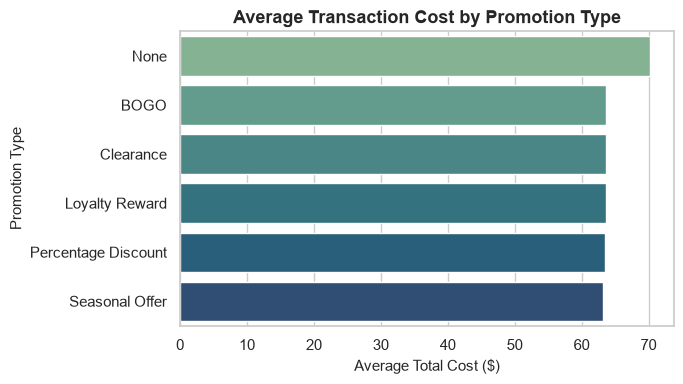


Highest average transaction value: 'None' ($70.29)


In [16]:
# ---- Which promotion type is most effective at increasing total cost? ----
avg_cost_by_promo = (
    df.groupby("Promotion")["Total_Cost"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_cost_by_promo)

plt.figure(figsize=(7, 4))
sns.barplot(x=avg_cost_by_promo.values, y=avg_cost_by_promo.index, palette="crest")
plt.title("Average Transaction Cost by Promotion Type")
plt.xlabel("Average Total Cost ($)")
plt.ylabel("Promotion Type")
plt.tight_layout()
plt.show()

best_promo = avg_cost_by_promo.index[0]
print(f"\nHighest average transaction value: '{best_promo}' (${avg_cost_by_promo.iloc[0]:.2f})")


**Task 4 takeaways:** transactions **without** a discount have a meaningfully **higher** average
total cost than discounted ones — expected, since a discount mechanically reduces the amount
paid. Across promotion types, differences in basket size and average cost are small, with
**BOGO** edging out the others on both average items and average cost, making it the strongest
candidate promotion type in this sample when the goal is maximising transaction value.


## Task 5: Seasonality Trends

Season
Winter   1,688,675.06
Spring   1,715,826.96
Summer   1,724,509.98
Fall     1,718,316.20
Name: Total_Cost, dtype: float64


C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\2529278590.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_season.index, y=revenue_by_season.values, palette=PALETTE)


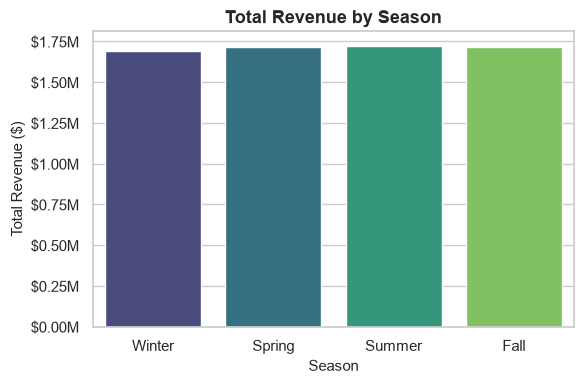

In [18]:
# ---- Which season has the highest total revenue? ----
revenue_by_season = (
    df.groupby("Season")["Total_Cost"]
    .sum()
    .reindex(["Winter", "Spring", "Summer", "Fall"])   # keep a natural seasonal order
)
print(revenue_by_season)

plt.figure(figsize=(6, 4))
sns.barplot(x=revenue_by_season.index, y=revenue_by_season.values, palette=PALETTE)
plt.title("Total Revenue by Season")
plt.ylabel("Total Revenue ($)")
plt.xlabel("Season")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e6:.2f}M"))
plt.tight_layout()
plt.show()


Store_Type  Convenience Store  Department Store     Online  Supermarket  \
Season                                                                    
Winter             341,744.00        169,607.00 253,411.00   664,713.00   
Spring             335,461.00        171,956.00 259,585.00   685,448.00   
Summer             350,006.00        169,176.00 265,302.00   684,369.00   
Fall               350,523.00        172,986.00 255,175.00   683,694.00   

Store_Type  Warehouse Club  
Season                      
Winter          259,200.00  
Spring          263,378.00  
Summer          255,656.00  
Fall            255,939.00  

Top store type per season:
Season
Winter    Supermarket
Spring    Supermarket
Summer    Supermarket
Fall      Supermarket
dtype: str


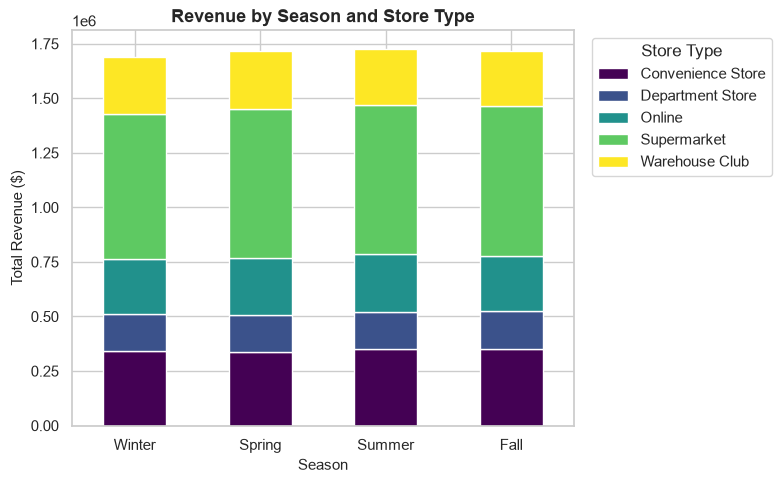

In [19]:
# ---- Seasonal preferences for store types ----
season_store_revenue = (
    df.groupby(["Season", "Store_Type"])["Total_Cost"]
    .sum()
    .unstack()
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)
print(season_store_revenue.round(0))
print("\nTop store type per season:")
print(season_store_revenue.idxmax(axis=1))

season_store_revenue.plot(kind="bar", stacked=True, figsize=(8, 5), colormap=PALETTE)
plt.title("Revenue by Season and Store Type")
plt.ylabel("Total Revenue ($)")
plt.xlabel("Season")
plt.xticks(rotation=0)
plt.legend(title="Store Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [21]:
# ---- Seasonal preferences for products (top product per season) ----
season_products = (
    df[["Season", "Product"]]
    .assign(Product=df["Product"].str.split(",\\s*"))
    .explode("Product")
    .groupby(["Season", "Product"])
    .size()
    .reset_index(name="Count")
)
top_product_per_season = (
    season_products.sort_values("Count", ascending=False)
    .groupby("Season")
    .head(1)
    .set_index("Season")
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)
print(top_product_per_season)


              Product  Count
Season                      
Winter        Vinegar   2198
Spring         Butter   2246
Summer      BBQ Sauce   2267
Fall    Peanut Butter   2262


Season
Winter   68.51
Spring   68.43
Summer   68.34
Fall     68.63
Name: Total_Cost, dtype: float64


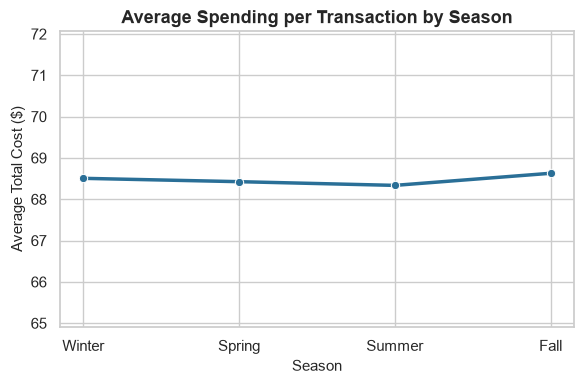

In [23]:
# ---- Plot: average spending per season ----
avg_spend_by_season = (
    df.groupby("Season")["Total_Cost"]
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)
print(avg_spend_by_season)

plt.figure(figsize=(6, 4))
sns.lineplot(x=avg_spend_by_season.index, y=avg_spend_by_season.values, marker="o", linewidth=2.5, color="#2a6f97")
plt.title("Average Spending per Transaction by Season")
plt.ylabel("Average Total Cost ($)")
plt.xlabel("Season")
plt.ylim(avg_spend_by_season.min() * 0.95, avg_spend_by_season.max() * 1.05)
plt.tight_layout()
plt.show()


**Task 5 takeaways:** total revenue is fairly evenly spread across the four seasons, with
**Summer and Fall** contributing marginally more than Winter — likely reflecting slightly higher
transaction volumes rather than a strong seasonal spending effect. **Supermarket** is the top
revenue-generating store type in every season, and the average transaction value moves only
within a narrow band (~$68–69) across seasons, indicating spend-per-visit is stable year-round
even if total volume shifts slightly.


## Task 6: Visualisation Dashboard

C:\Users\Nagarajan Kanagamani\AppData\Local\Temp\ipykernel_17096\2399967722.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transactions_per_city.values, y=transactions_per_city.index, palette=PALETTE)


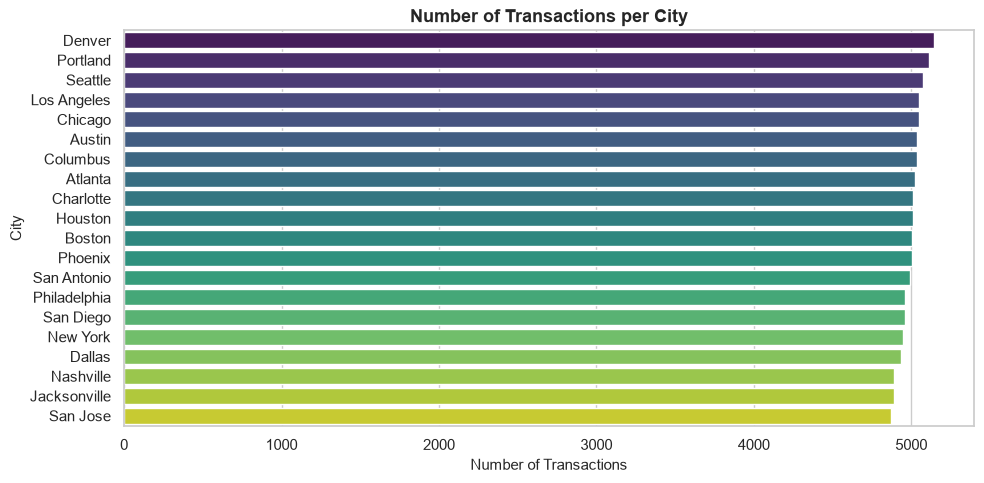

In [24]:
# ---- 1. Bar plot: number of transactions per city ----
transactions_per_city = df["City"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=transactions_per_city.values, y=transactions_per_city.index, palette=PALETTE)
plt.title("Number of Transactions per City")
plt.xlabel("Number of Transactions")
plt.ylabel("City")
plt.tight_layout()
plt.show()


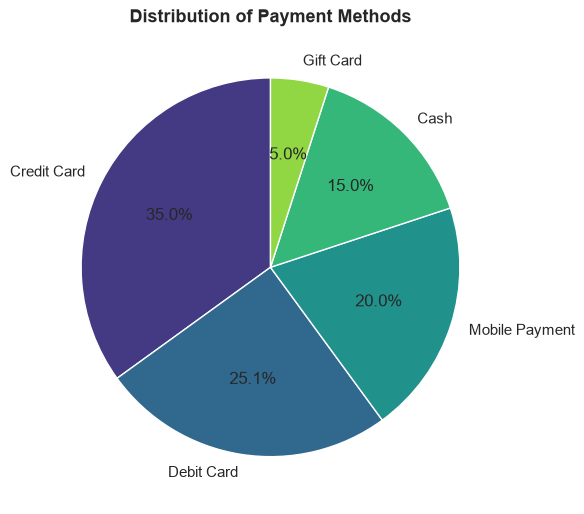

In [25]:
# ---- 2. Pie chart: distribution of payment methods ----
payment_dist = df["Payment_Method"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette(PALETTE, len(payment_dist)),
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Distribution of Payment Methods")
plt.tight_layout()
plt.show()


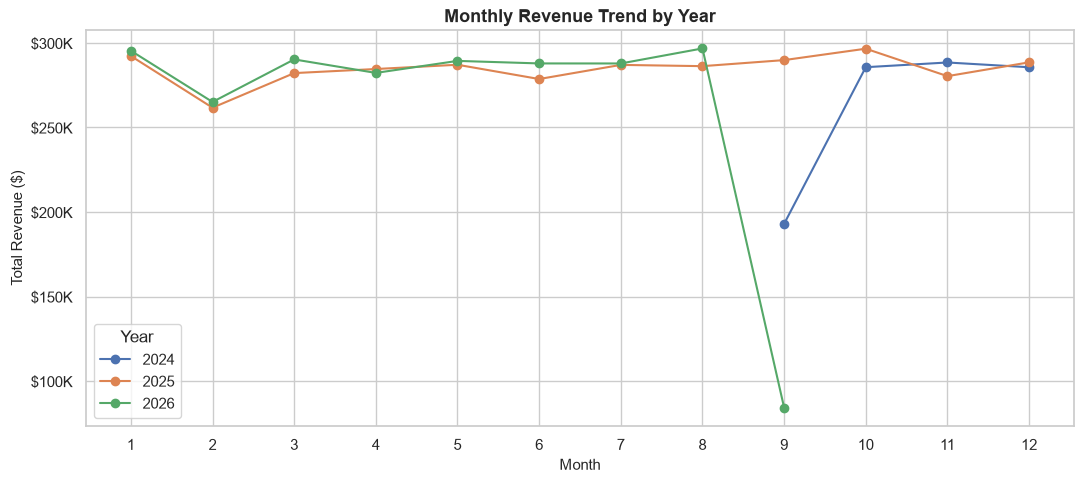

Note: the most recent calendar month in the data may be partial (data extraction date falls mid-month), which can make it look artificially low - check the row count for that month before reading too much into a dip at the very end of the series.


In [26]:
# ---- 3. Line chart: monthly revenue trend (by calendar month, split by year) ----
monthly_revenue = df.groupby(["Year", "Month"])["Total_Cost"].sum().reset_index()

plt.figure(figsize=(11, 5))
for yr, grp in monthly_revenue.groupby("Year"):
    plt.plot(grp["Month"], grp["Total_Cost"], marker="o", label=str(yr))

plt.title("Monthly Revenue Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))
plt.tight_layout()
plt.show()

print("Note: the most recent calendar month in the data may be partial (data extraction date "
      "falls mid-month), which can make it look artificially low - check the row count for that "
      "month before reading too much into a dip at the very end of the series.")


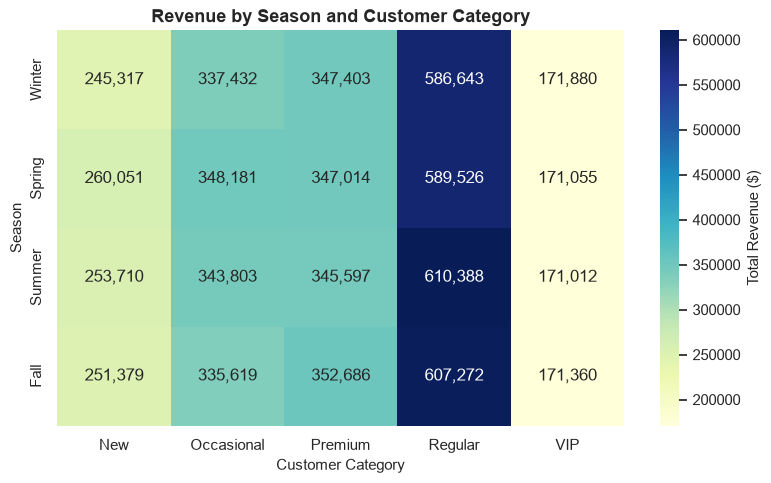

In [27]:
# ---- 4. Heatmap: revenue by season and customer category ----
season_category_revenue = (
    df.groupby(["Season", "Customer_Category"])["Total_Cost"]
    .sum()
    .unstack()
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)

plt.figure(figsize=(8, 5))
sns.heatmap(season_category_revenue, annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={"label": "Total Revenue ($)"})
plt.title("Revenue by Season and Customer Category")
plt.xlabel("Customer Category")
plt.ylabel("Season")
plt.tight_layout()
plt.show()


## Summary: Key Insights & Recommended Actions

### Key Insights

- **Scale:** the dataset contains 100,000 transactions from roughly 7,500 unique customers
  (~13 transactions per customer on average), spanning two full years.
- **Product mix:** the top-selling products (BBQ Sauce, Granola, Jam, Milk, Butter) sell at very
  similar volumes, and no single item dominates the basket — the catalogue is broad rather than
  hit-driven.
- **Geography:** transaction volume is fairly evenly distributed across the tracked cities, with
  Denver, Portland, Seattle, Los Angeles and Chicago the busiest — useful for prioritising local
  marketing spend or staffing.
- **Customer segments:** average spend per transaction is similar across Regular, Premium,
  Occasional, VIP and New customers (all within a couple of dollars of ~$68). **Credit Card is
  the preferred payment method for every segment** (roughly 35% of transactions), followed by
  Debit Card and Mobile Payment.
- **Store format:** basket size (items per transaction) is consistent across formats, with
  Warehouse Club and Online running marginally larger — consistent with bulk or stock-up
  shopping missions.
- **Discounts:** discounted transactions cost noticeably less on average than non-discounted
  ones, as expected. Among promotion types, **BOGO** shows the highest average items and average
  transaction value, making it the most effective lever in this sample for lifting basket value.
- **Seasonality:** total revenue is fairly flat across seasons (Summer and Fall slightly ahead of
  Winter and Spring), and average spend per transaction stays within a narrow ~$68–69 band all
  year. Supermarket is the top revenue-generating store type in every season.

### Recommended Actions

- **Lead promotions with BOGO** where the goal is maximising transaction value, since it
  outperforms percentage discounts, clearance and loyalty rewards on both basket size and spend
  in this data.
- **Protect margin on discounts** by monitoring the ~15–20% average-cost gap between discounted
  and full-price transactions, and target discounts at slower-moving products rather than
  applying them broadly.
- **Prioritise Credit/Debit card checkout experience** (fees, rewards partnerships, checkout
  speed) since together they cover roughly 60% of all payments, with Mobile Payment a fast-growing
  third option worth continued investment.
- **Use Supermarket as the anchor format** for seasonal campaigns given its consistent revenue
  lead, while testing targeted Warehouse Club / Online promotions to grow their slightly larger
  average basket size further.
- **Prioritise the top five cities** (Denver, Portland, Seattle, Los Angeles, Chicago) for local
  promotions or new-store investment, since they already generate the most transaction volume.
- **Re-run this analysis periodically** (e.g. monthly) once a full, non-partial month of data is
  available, so the monthly revenue trend and seasonal comparisons reflect complete periods only.

*Note: this sample dataset shows relatively uniform behaviour across segments/seasons — in a
production setting with real transaction data, the same notebook structure can be re-run to
surface sharper, more actionable differences.*
